## Simple Poisson Solver

## Visualizating the results

Below we give some python code to visualizate the solution using yt:

In [1]:
import yt
from yt.frontends import boxlib
from yt.frontends.boxlib.data_structures import AMReXDataset
import numpy as np
import matplotlib.pyplot as plt
import os
import scipy as sp

N = 128
N2 = N // 2

/tmp/ipykernel_3246258/3995322757.py:3: DeprecationWarning: The historic 'boxlib' frontend is 
deprecated as it has been renamed 'amrex'. Existing and future work should instead reference the 'amrex' frontend.
Deprecated since yt 4.4.0
  from yt.frontends.boxlib.data_structures import AMReXDataset


In [2]:
ls

 animate_gaus.ipynb         'density weird.png'
 animate_pot.ipynb           ExtrapolateA.ipynb
 animate_slice.ipynb         NumericalSolver.ipynb
 animate_vol.ipynb           Phase_plot.ipynb
'animation Edens.gif'        plt00000_Slice_x_density.png
'animation Edens.mp4'        plt00000_Slice_x_Edens.png
'animation Edens_pr.gif'     plt00000_Slice_x_PhiGrav.png
'animation Egrad.mp4'        plt00000_Slice_z_density.png
'animation Ekin.mp4'         plt00000_Slice_z_Edens.png
'animation Epot.mp4'         plt00000_Slice_z_PhiGrav.png
'animation KGf.gif'          plt09800_Slice_z_PhiGrav.png
'animation KGfpr.mp4'        plt09800_Slice_z_PhiGrav_pr.png
'animation KGfv.gif'         profiles.ipynb
'animation PhiGrav_pr.gif'   SplitEnergies.ipynb
'animation PhiGrav_pr.mp4'   Untitled.ipynb
 CalcGrad.ipynb              Visualization.ipynb


### Energy Density

In [10]:
ds = AMReXDataset("../Outputs/plt00001")

yt : [INFO     ] 2026-08-24 12:04:16,313 Parameters: current_time              = 0.01
yt : [INFO     ] 2026-08-24 12:04:16,314 Parameters: domain_dimensions         = [128 128 128]
yt : [INFO     ] 2026-08-24 12:04:16,314 Parameters: domain_left_edge          = [0. 0. 0.]
yt : [INFO     ] 2026-08-24 12:04:16,314 Parameters: domain_right_edge         = [20. 20. 20.]


In [11]:
ds

AMReXDataset: /home/lsou343/Scalarverse/scalarverse-main/Exec/Inflation/Newtonian/Outputs/plt00001

In [12]:
ds.field_list

[('boxlib', 'Edens'),
 ('boxlib', 'Edens_pr'),
 ('boxlib', 'Egrad'),
 ('boxlib', 'Ekin'),
 ('boxlib', 'Epot'),
 ('boxlib', 'KGf'),
 ('boxlib', 'KGfVpr'),
 ('boxlib', 'KGfdens'),
 ('boxlib', 'KGfpr'),
 ('boxlib', 'KGfv'),
 ('boxlib', 'PhiGrav'),
 ('boxlib', 'PhiGravV_pr'),
 ('boxlib', 'PhiGrav_pr')]

yt : [INFO     ] 2026-08-24 12:04:22,216 xlim = 0.000000 20.000000
yt : [INFO     ] 2026-08-24 12:04:22,216 ylim = 0.000000 20.000000
yt : [INFO     ] 2026-08-24 12:04:22,218 xlim = 0.000000 20.000000
yt : [INFO     ] 2026-08-24 12:04:22,218 ylim = 0.000000 20.000000
yt : [INFO     ] 2026-08-24 12:04:22,219 Making a fixed resolution buffer of (('boxlib', 'Edens_pr')) 800 by 800



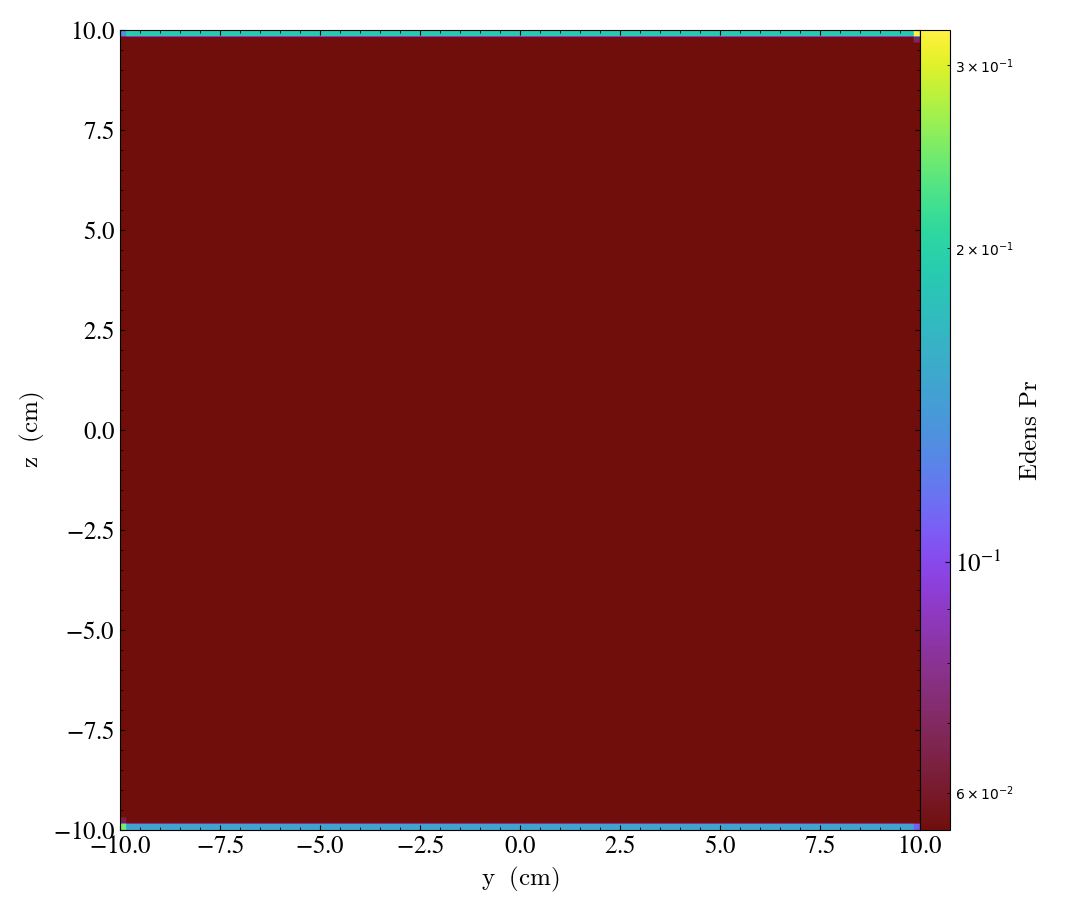

In [14]:
sl = yt.SlicePlot(ds, 0, ('boxlib', 'Edens_pr'))
sl


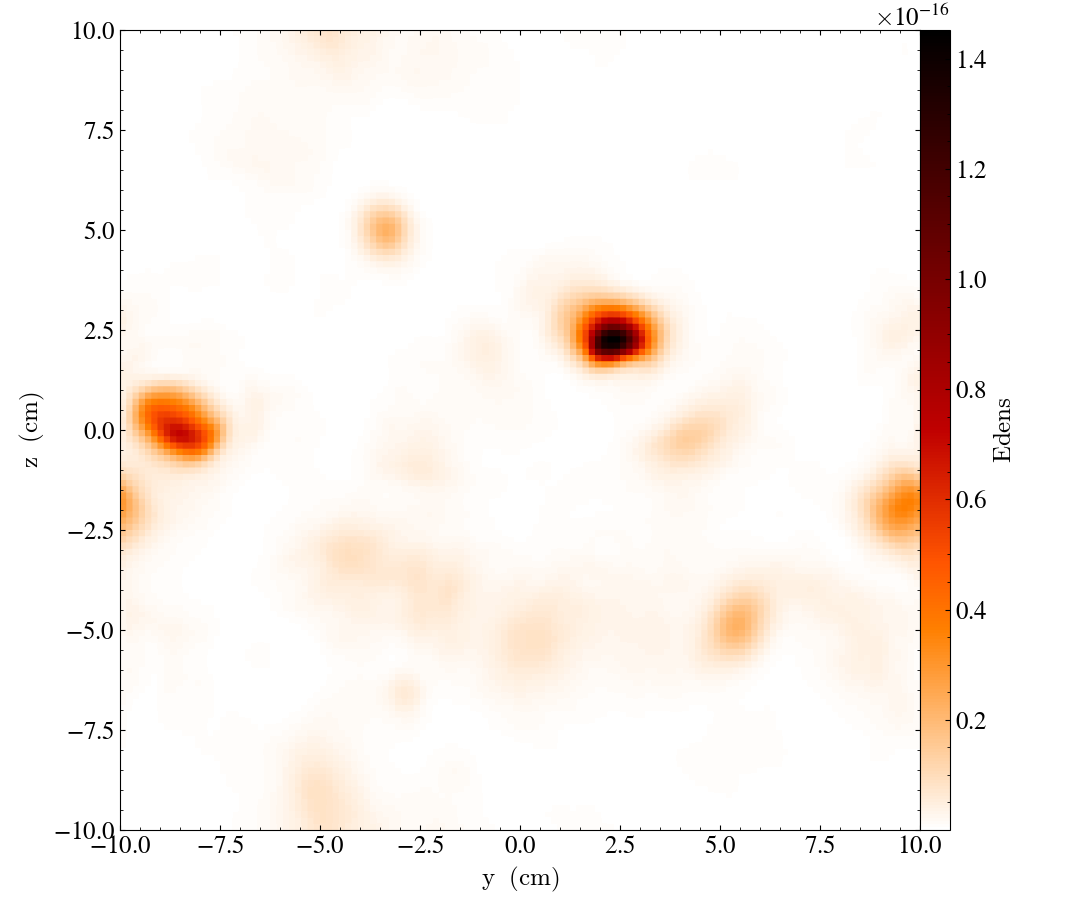

In [6]:
sl.set_log("Edens",False)
sl.set_cmap(("Edens"), "gist_heat_r")
sl

In [9]:
sl.save()

yt : [INFO     ] 2026-08-24 11:42:36,488 Saving plot plt00001_Slice_z_Edens_pr.png


['plt00001_Slice_z_Edens_pr.png']

### Newtonian Potential

yt : [INFO     ] 2026-08-06 12:39:45,716 xlim = 0.000000 20.000000
yt : [INFO     ] 2026-08-06 12:39:45,717 ylim = 0.000000 20.000000
yt : [INFO     ] 2026-08-06 12:39:45,719 xlim = 0.000000 20.000000
yt : [INFO     ] 2026-08-06 12:39:45,719 ylim = 0.000000 20.000000
yt : [INFO     ] 2026-08-06 12:39:45,720 Making a fixed resolution buffer of (('boxlib', 'PhiGrav')) 800 by 800



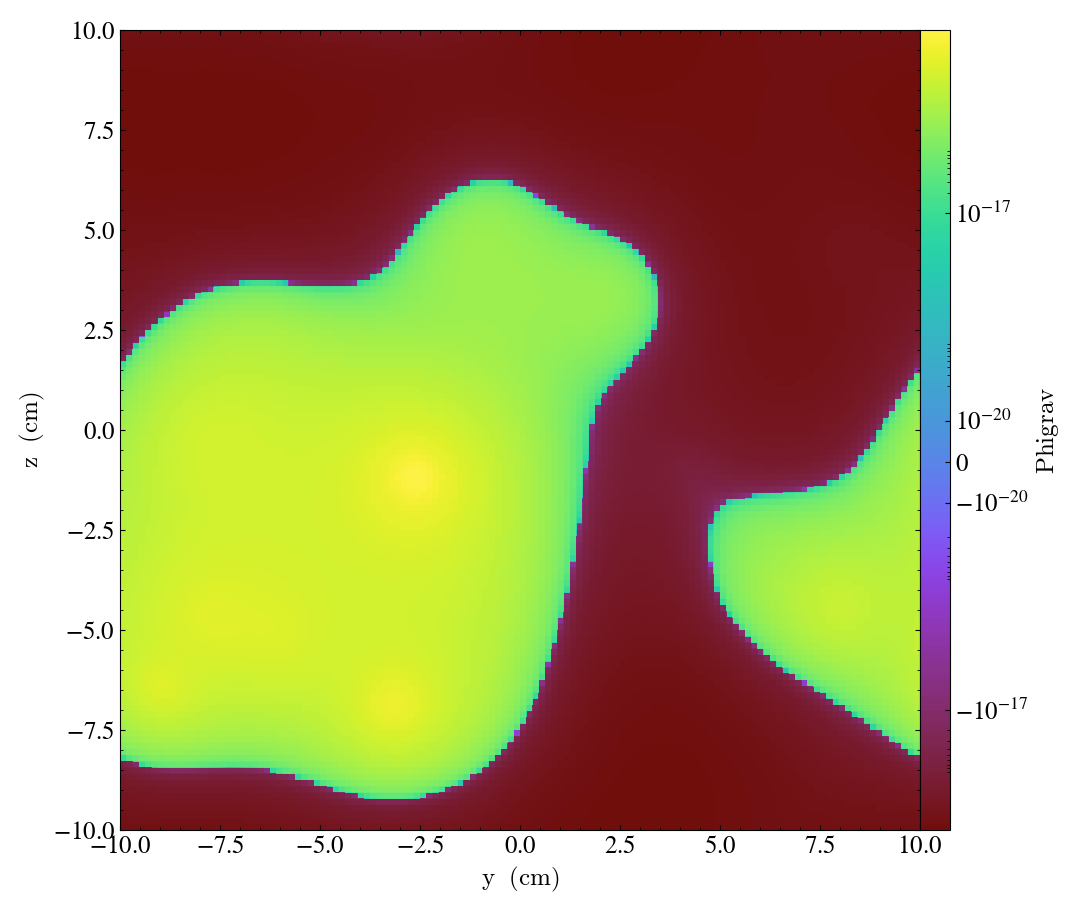

In [18]:
sl2 = yt.SlicePlot(ds, 0, ('boxlib', 'PhiGrav'))
sl2

In [8]:
all_data_level_0 = ds.covering_grid(level=0, left_edge=[0,0,0],dims=[128,128,128])
print(all_data_level_0["boxlib","PhiGrav"][0,0,:])
PhiGrav = all_data_level_0["boxlib","PhiGrav"]
print(PhiGrav.max()-PhiGrav.min())

[-4.03193863e-16 -4.49177165e-16 -4.96874367e-16 -5.45623642e-16
 -5.94770186e-16 -6.43655101e-16 -6.91662750e-16 -7.38271819e-16
 -7.83113346e-16 -8.25973452e-16 -8.66828849e-16 -9.05747010e-16
 -9.42720516e-16 -9.77632264e-16 -1.01022660e-15 -1.04014793e-15
 -1.06701219e-15 -1.09050394e-15 -1.11033482e-15 -1.12623986e-15
 -1.13804092e-15 -1.14561989e-15 -1.14883921e-15 -1.14746348e-15
 -1.14120474e-15 -1.12981185e-15 -1.11311364e-15 -1.09107604e-15
 -1.06381436e-15 -1.03145852e-15 -9.93889050e-16 -9.50495677e-16
 -9.00323675e-16 -8.42342658e-16 -7.75596099e-16 -6.99272976e-16
 -6.12576140e-16 -5.14394605e-16 -4.03252519e-16 -2.77514271e-16
 -1.35514066e-16  2.41140119e-17  2.02310059e-16  4.00679973e-16
  6.21976601e-16  8.69526121e-16  1.14668433e-15  1.45621160e-15
  1.79922808e-15  2.17448266e-15  2.57842431e-15  3.00242325e-15
  3.42746296e-15  3.82206070e-15  4.14654770e-15  4.36464293e-15
  4.45310823e-15  4.40543689e-15  4.23240666e-15  3.95999573e-15
  3.62210110e-15  3.25264


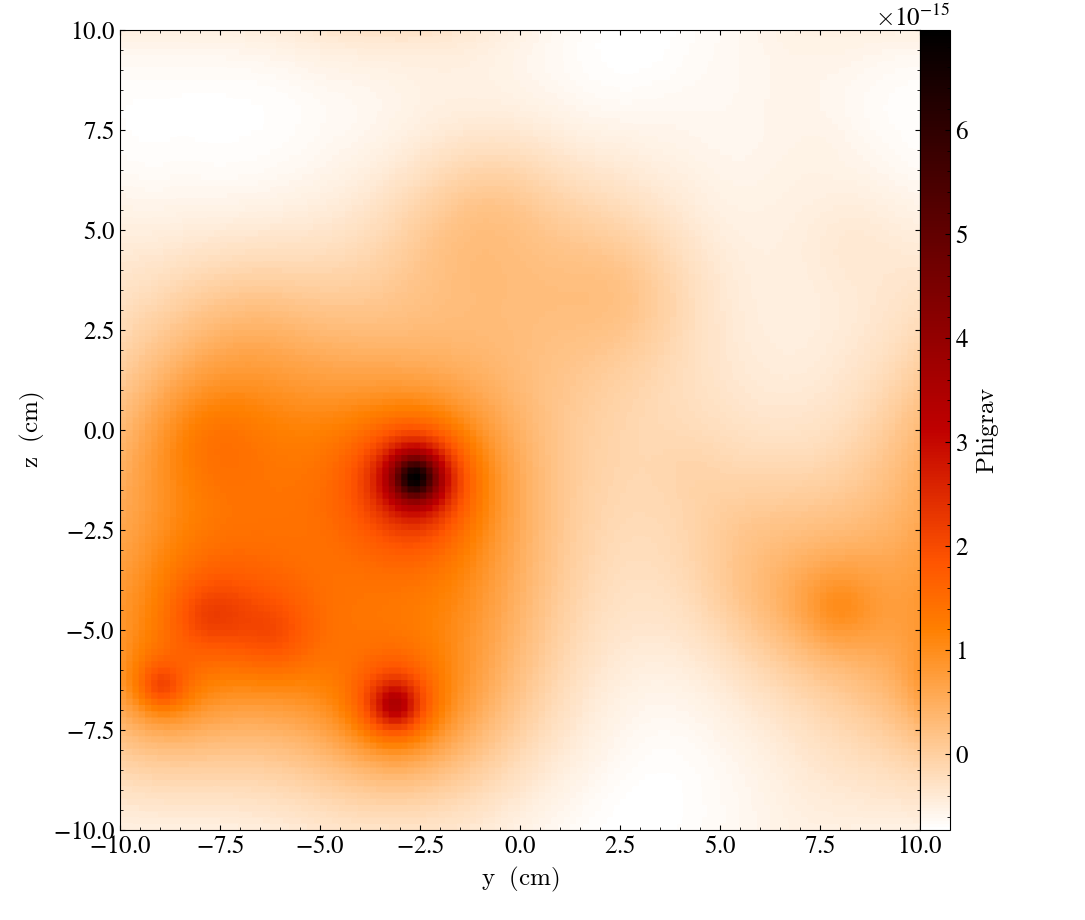

In [19]:
sl2.set_log("PhiGrav",False)
sl2.set_cmap(("PhiGrav"), "gist_heat_r")
sl2

In [12]:
sl2.save()

yt : [INFO     ] 2026-07-31 14:03:46,488 Saving plot plt00000_Slice_x_PhiGrav.png


['plt00000_Slice_x_PhiGrav.png']

yt : [INFO     ] 2026-08-06 12:29:03,667 xlim = 0.000000 20.000000
yt : [INFO     ] 2026-08-06 12:29:03,668 ylim = 0.000000 20.000000
yt : [INFO     ] 2026-08-06 12:29:03,669 xlim = 0.000000 20.000000
yt : [INFO     ] 2026-08-06 12:29:03,670 ylim = 0.000000 20.000000
yt : [INFO     ] 2026-08-06 12:29:03,670 Making a fixed resolution buffer of (('boxlib', 'KGfpr')) 800 by 800



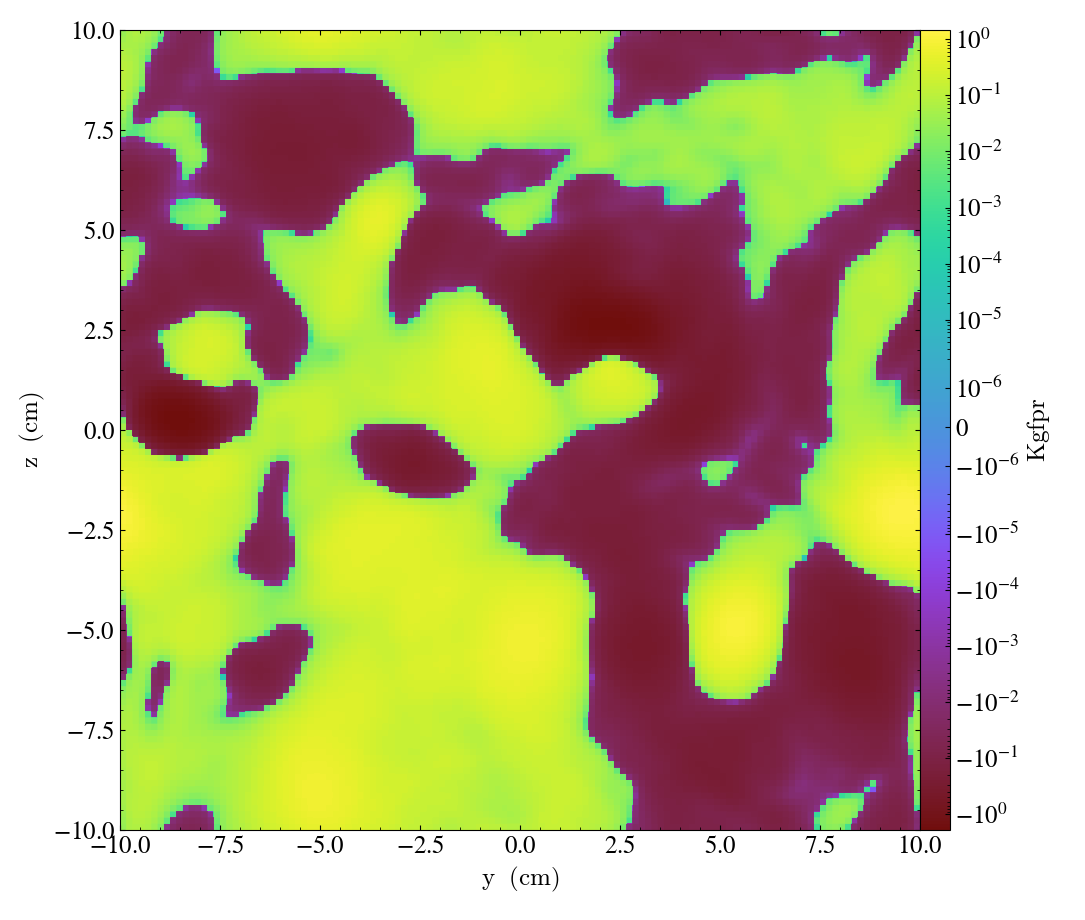

In [15]:
sl3 = yt.SlicePlot(ds, 0, ('boxlib', 'KGfpr'))
sl3

In [104]:
data0 = ds.covering_grid(level=0, left_edge=[0,0,0],dims=[128,128,128])
print(data0["boxlib","KGfpr"])
data = data0["boxlib","KGfpr"]

[[[-0.31880177 -0.30764442 -0.29432513 ... -0.32640009 -0.32886759
   -0.32581009]
  [-0.3230833  -0.31435086 -0.30428889 ... -0.32626221 -0.32998318
   -0.32786168]
  [-0.326728   -0.32116545 -0.31361411 ... -0.3211428  -0.32690289
   -0.32871165]
  ...
  [-0.27130757 -0.26595519 -0.25933251 ... -0.2724206  -0.27551909
   -0.27446269]
  [-0.2942722  -0.28507399 -0.27341585 ... -0.29796287 -0.30150685
   -0.29973042]
  [-0.31065411 -0.29872571 -0.28490646 ... -0.31657408 -0.31982251
   -0.31759946]]

 [[-0.3079435  -0.30646449 -0.29839816 ... -0.28635967 -0.29550369
   -0.30285222]
  [-0.313052   -0.31395464 -0.30965715 ... -0.29013167 -0.29913225
   -0.30715542]
  [-0.32007117 -0.32380992 -0.32210911 ... -0.28992303 -0.3015712
   -0.3120483 ]
  ...
  [-0.27296302 -0.27203083 -0.2659334  ... -0.25292025 -0.26353111
   -0.27024633]
  [-0.28940706 -0.28712779 -0.27875396 ... -0.26528734 -0.27678425
   -0.28516646]
  [-0.30076035 -0.29884797 -0.28941465 ... -0.27750354 -0.28816106
   -0.2

In [24]:
N=128
L = 20

def incr(n):
    if n == N-1:
        return 0
    else:
        return n + 1

def decr(n):
    if n == 0:
        return N-1
    else:
        return n - 1

In [ ]:
grad_phi = np.zeros((N,N,N))
for i in range(N):
    for j in range(N):
        for k in range(N):
            grad_phi[i,j,k] = ((data[incr(i),j,k] - data[decr(i),j,k]) ** 2 +
                               (data[i,incr(j),k] - data[i,decr(j),k]) ** 2 +
                               (data[i,j,incr(k)] - data[i,j,decr(k)]) ** 2
                               )
grad_phi /= 8 * (L / N) ** 2

IndexError: index 511 is out of bounds for axis 0 with size 128

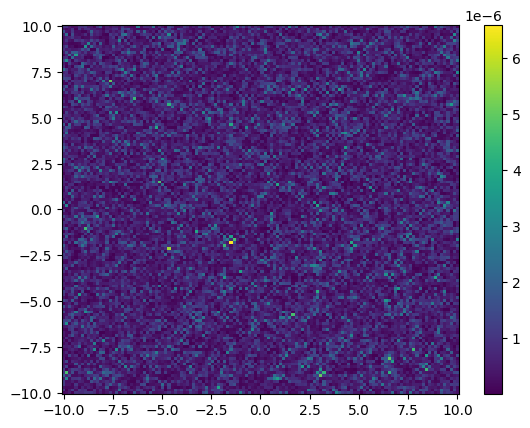

In [40]:
xs = np.linspace(-10,10,128)
x,y = np.meshgrid(xs,xs,indexing='ij')
plt.pcolormesh(x,y,grad_phi[64,:,:])
plt.colorbar()

Comparison of $\nabla^2 \Phi$ and $4\pi(\rho-\langle \rho \rangle)$

In [59]:
N=128
L = 20
rhs = ds.covering_grid(level=0, left_edge=[0,0,0],dims=[N,N,N])["boxlib","density"]
#rhs -= np.mean(rhs)
#rhs *= 4 * np.pi

In [48]:
data = ds.covering_grid(level=0, left_edge=[0,0,0],dims=[N,N,N])["boxlib","PhiGrav"]
lhs = np.zeros((N,N,N))
# for i in range(128):
#     for j in range(128):
#         for k in range(128):
#             lhs[i,j,k] = ((data[incr(i),j,k] - data[decr(i),j,k]) +
#                           (data[i,incr(j),k] - data[i,decr(j),k]) +
#                           (data[i,j,incr(k)] - data[i,j,decr(k)]) -
#                           6 * data[i,j,k]
#                          )
j,k=N//2,N//2
for i in range(N):
    lhs[i,N//2,N//2] = ((data[incr(i),j,k] + data[decr(i),j,k]) +
                  (data[i,incr(j),k] + data[i,decr(j),k]) +
                  (data[i,j,incr(k)] + data[i,j,decr(k)]) -
                  6 * data[i,j,k]
                 )
    lhs[N//2,i,N//2] = ((data[incr(i),j,k] + data[decr(i),j,k]) +
                  (data[i,incr(j),k] + data[i,decr(j),k]) +
                  (data[i,j,incr(k)] + data[i,j,decr(k)]) -
                  6 * data[i,j,k]
                 )
    lhs[N//2,N//2,i] = ((data[incr(i),j,k] + data[decr(i),j,k]) +
                  (data[i,incr(j),k] + data[i,decr(j),k]) +
                  (data[i,j,incr(k)] + data[i,j,decr(k)]) -
                  6 * data[i,j,k]
                 )
lhs /= (L / N) ** 2

In [49]:
sigma = 0.5
r = np.arange(-L//2, L//2, L/N)
r[N//2] = 1e-16   # Avoid division by zero
r2 = np.linspace(-L//2, L//2, 1000)
ampl = 0.0232524067

In [50]:
coef = 1.128602693e15

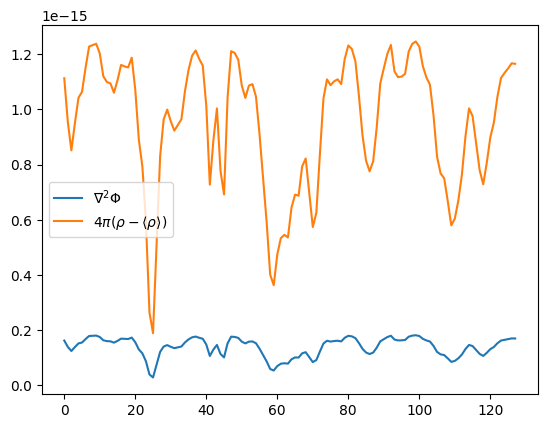

In [63]:
i,j,k = (N//2,N//2,N//2)

plt.plot(lhs[:,j,k], label=r"$\nabla^2 \Phi$")
plt.plot(-4*np.pi*(rhs[:,j,k] - np.mean(rhs)), label=r"$4\pi (\rho - \langle \rho \rangle)$")
#plt.plot(-ampl * np.sqrt(np.pi/2) * sigma ** 3 / r * sp.special.erf(r / sigma / np.sqrt(2)))
#plt.plot(ampl*np.exp(-0.5 * r**2 / sigma ** 2), label = "Analytical")
plt.plot()
plt.legend()

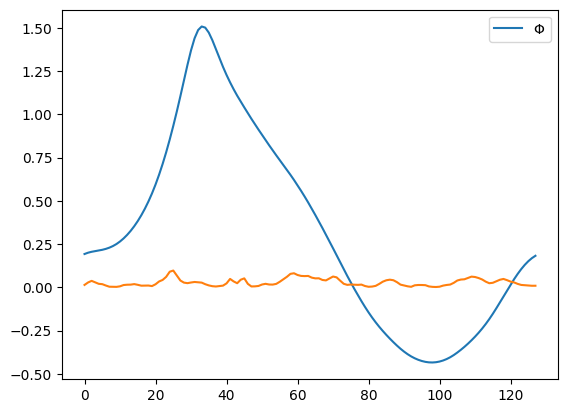

In [61]:
plt.plot(coef*data[:,j,k], label=r"$\Phi$")
plt.plot(coef*rhs[:,j,k])
#plt.plot(-ampl * np.sqrt(np.pi/2) * sigma ** 3 / r * sp.special.erf(r / sigma / np.sqrt(2)), label=r"Analytical $\Phi$")
plt.plot()
plt.legend()

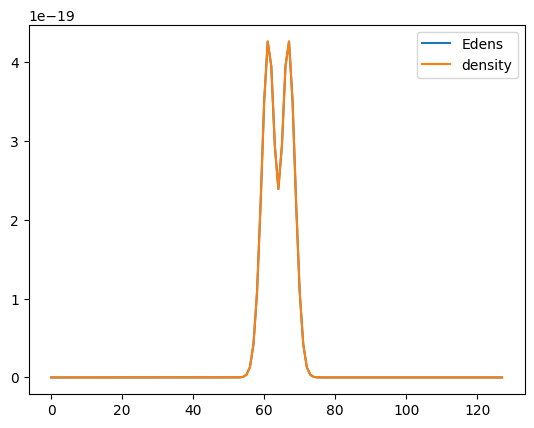

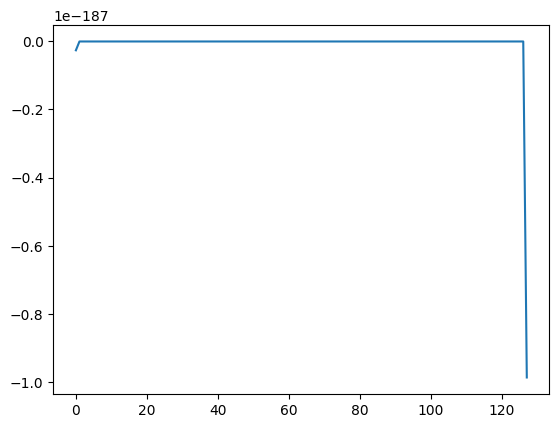

In [34]:
rhs1 = ds.covering_grid(level=0, left_edge=[0,0,0],dims=[128,128,128])["boxlib","Edens"]
rhs2 = ds.covering_grid(level=0, left_edge=[0,0,0],dims=[128,128,128])["boxlib","density"]
plt.plot(rhs1[:,j,k], label="Edens")
plt.plot(rhs2[:,j,k], label="density")
plt.legend()
plt.figure()
plt.plot(np.array(rhs1[:,j,k])-np.array(rhs2[:,j,k]))

<Figure size 640x480 with 0 Axes>

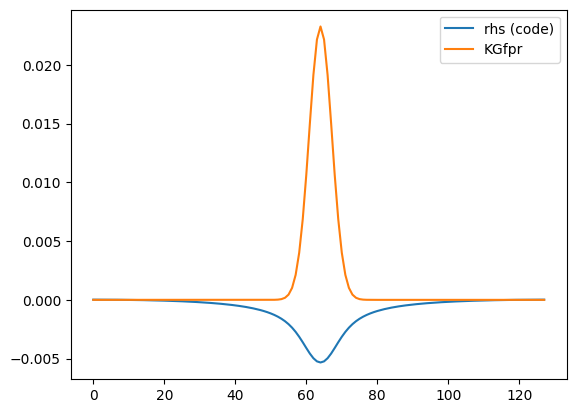

<Figure size 640x480 with 0 Axes>

In [17]:
rhs1 = ds.covering_grid(level=0, left_edge=[0,0,0],dims=[128,128,128])["boxlib","PhiGrav"]
rhs2 = ds.covering_grid(level=0, left_edge=[0,0,0],dims=[128,128,128])["boxlib","KGfpr"]
plt.plot(rhs1[:,64,64], label="rhs (code)")
plt.plot(rhs2[:,64,64], label="KGfpr")
plt.legend()
plt.figure()

### Compare Energy Density

In [103]:
all_data_level_0 = ds.covering_grid(level=0, left_edge=[0,0,0],dims=[128,128,128])
edens = all_data_level_0["boxlib","Edens"]
density = all_data_level_0["boxlib","density"]
diff = np.array(edens) - np.array(density)
print(np.sum(diff ** 2))

3.395702785305932e-25


### Relative Energy Density

1.0090870504076309e-16 code_mass/code_length**3


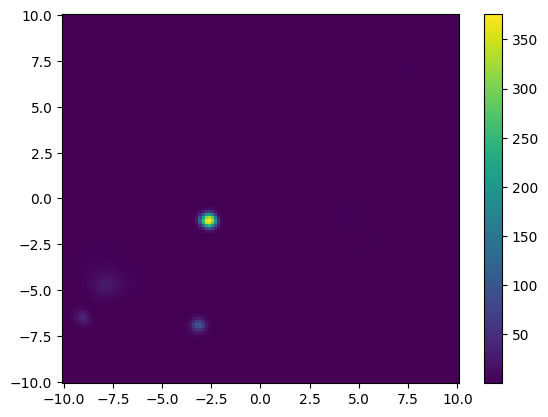

In [17]:
all_data_level_0 = ds.covering_grid(level=0, left_edge=[0,0,0],dims=[128,128,128])
density = all_data_level_0["boxlib","density"]
avg_density = np.sum(density / 128 ** 3)
print(avg_density)
density_rel = density / avg_density
xs = np.linspace(-10,10,128)
x,y = np.meshgrid(xs,xs,indexing='ij')
plt.pcolormesh(x,y,density_rel[64,:,:])
plt.colorbar()